# XGBoost Binary Classifier (GPU + Optuna + Global Threshold Calibration)
Optimized for Precision-heavy Metric (F0.5) with Singleton Handling.
Simplified global threshold search applied.


### 1. Imports and Configuration


In [1]:
import os, gc, time, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

import warnings

# Suppress all future and runtime warnings globally
warnings.filterwarnings('ignore')


try:
    import optuna
except ImportError:
    os.system("pip install -q optuna")
    import optuna

try:
    from tqdm.auto import tqdm
except ImportError:
    os.system("pip install -q tqdm")
    from tqdm.auto import tqdm

import joblib

DATA_PATH = Path('/kaggle/input/datasets/vinaysingh120221/training-data-01/training_features_full.csv')
OUTPUT_DIR = Path('/kaggle/working/xgboost_classifier')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
VALIDATION_FRACTION = 0.2
N_TRIALS = 20
USE_GPU = True


### 2. Loading Data


In [2]:
print("[INFO] Loading data in chunks to save RAM...")
chunk_size = 1000000  # 1 million rows at a time
chunks = []

for chunk in pd.read_csv(DATA_PATH, dtype={"query_id": str, "candidate_id": str}, chunksize=chunk_size):
    chunk['label'] = chunk['label'].astype(np.int8)
    feature_cols = [c for c in chunk.columns if c not in ['query_id', 'candidate_id', 'label']]
    for c in feature_cols:
        chunk[c] = pd.to_numeric(chunk[c], errors='coerce').fillna(0.0).astype(np.float32)
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

FEATURE_COLUMNS = feature_cols
print(f"Shape: {df.shape} | Features: {len(FEATURE_COLUMNS)}")
print(f"Total RAM usage of dataframe: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")


[INFO] Loading data in chunks to save RAM...
Shape: (1048575, 36) | Features: 33
Total RAM usage of dataframe: 0.27 GB


### 3. Query Partitioned Split


In [3]:
def query_partitioned_split(dataset_df, val_fraction=0.2, random_state=42):
    unique_queries = np.array(sorted(dataset_df["query_id"].unique()))
    rng = np.random.default_rng(random_state)
    rng.shuffle(unique_queries)
    val_size = max(1, int(len(unique_queries) * val_fraction))
    val_query_set = set(unique_queries[:val_size])
    
    train_df = dataset_df[~dataset_df["query_id"].isin(val_query_set)].copy()
    val_df = dataset_df[dataset_df["query_id"].isin(val_query_set)].copy()
    
    train_df = train_df.sort_values("query_id").reset_index(drop=True)
    val_df = val_df.sort_values("query_id").reset_index(drop=True)
    return train_df, val_df

train_df, val_df = query_partitioned_split(df, val_fraction=VALIDATION_FRACTION, random_state=RANDOM_STATE)
X_train, y_train = train_df[FEATURE_COLUMNS], train_df["label"].to_numpy(dtype=np.int32)
X_val, y_val = val_df[FEATURE_COLUMNS], val_df["label"].to_numpy(dtype=np.int32)


### 4. Custom Metrics & Threshold Tuner (No Margin Sweep)


In [4]:
# Pre-compute Ground Truth Dicts for Evaluation
val_y_true_by_query = val_df[val_df['label'] == 1].groupby('query_id')['candidate_id'].apply(set).to_dict()
val_all_queries = set(val_df['query_id'].unique())

def macro_f05(y_true_by_query, pred_by_query, all_queries):
    scores = []
    # Using a fast list comprehension for the loop
    for qid in all_queries:
        true_set = y_true_by_query.get(qid, set())
        pred_set = pred_by_query.get(qid, set()) # Already a set now
        if not true_set:
            scores.append(1.0 if not pred_set else 0.0)
        else:
            tp = len(true_set & pred_set)
            precision = tp / len(pred_set) if pred_set else 0.0
            recall = tp / len(true_set)
            if precision == 0 and recall == 0:
                scores.append(0.0)
            else:
                scores.append((1.25 * precision * recall) / (0.25 * precision + recall))
    return np.mean(scores)

def exhaustive_threshold_search(val_preds_df, fast_mode=False):
    print("[INFO] Running Threshold Sweep...")
    
    best_f05 = -1
    best_config = {}
    
    from collections import defaultdict
    qids = val_preds_df['query_id'].values
    cids = val_preds_df['candidate_id'].values
    scores = val_preds_df['score'].values
    
    unique_scores = np.sort(val_preds_df['score'].unique())[::-1]
    pct_count = 20 if fast_mode else 100
    test_thresh = np.percentile(unique_scores, np.linspace(0, 100, pct_count))
    
    for t in tqdm(test_thresh, desc="Global Threshold Sweep", disable=fast_mode):
        mask = (scores >= t)
        
        pred_dict = defaultdict(set)
        for q, c in zip(qids[mask], cids[mask]):
            pred_dict[q].add(c)
            
        score = macro_f05(val_y_true_by_query, pred_dict, val_all_queries)
        if score > best_f05:
            best_f05 = score; best_config = {'threshold': t}
                
    return best_f05, best_config


### 5. Hyperparameter Tuning (Optuna)


In [5]:
try:
    import xgboost as xgb
except ImportError:
    os.system("pip install -q xgboost")
    import xgboost as xgb

print("[INFO] Tuning XGBoost Classifier...")
def objective(trial):
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "tree_method": "hist",
        "device": "cuda" if USE_GPU else "cpu",
        "learning_rate": trial.suggest_categorical("learning_rate", [0.02, 0.05, 0.1]),
        "n_estimators": 500,
        "max_depth": trial.suggest_int("max_depth", 4, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "subsample": trial.suggest_categorical("subsample", [0.7, 0.85, 1.0]),
        "colsample_bytree": trial.suggest_categorical("colsample_bytree", [0.7, 0.85, 1.0]),
        "reg_alpha": trial.suggest_categorical("reg_alpha", [0, 0.1, 1.0]),
        "reg_lambda": trial.suggest_categorical("reg_lambda", [0.1, 1.0, 5.0]),
        "n_jobs": -1,
        "random_state": RANDOM_STATE
    }
    
    clf = xgb.XGBClassifier(**params)
    clf.fit(
        X_train, y_train, 
        eval_set=[(X_val, y_val)], 
        verbose=False
    )
    
    val_preds = val_df[['query_id', 'candidate_id', 'label']].copy()
    val_preds['score'] = clf.predict_proba(X_val)[:, 1]
    best_f05, _ = exhaustive_threshold_search(val_preds, fast_mode=True)
    return best_f05

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"\n🏆 Best Macro F0.5: {study.best_value:.5f}")
print(f"🏆 Best Params: {study.best_params}")


[I 2026-09-29 01:03:36,380] A new study created in memory with name: no-name-42f8ff7e-6d37-49a3-bdd9-06bf457fb787


[INFO] Tuning XGBoost Classifier...


  0%|          | 0/20 [00:00<?, ?it/s]

[INFO] Running Threshold Sweep...
[I 2026-09-29 01:03:48,852] Trial 0 finished with value: 0.9548002875348992 and parameters: {'learning_rate': 0.02, 'max_depth': 9, 'min_child_weight': 4, 'subsample': 1.0, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1.0}. Best is trial 0 with value: 0.9548002875348992.
[INFO] Running Threshold Sweep...
[I 2026-09-29 01:03:56,040] Trial 1 finished with value: 0.9464423597699695 and parameters: {'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 3, 'subsample': 0.85, 'colsample_bytree': 1.0, 'reg_alpha': 0, 'reg_lambda': 1.0}. Best is trial 0 with value: 0.9548002875348992.
[INFO] Running Threshold Sweep...
[I 2026-09-29 01:04:03,028] Trial 2 finished with value: 0.9507649809988852 and parameters: {'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 1.0, 'colsample_bytree': 0.7, 'reg_alpha': 0, 'reg_lambda': 1.0}. Best is trial 0 with value: 0.9548002875348992.
[INFO] Running Threshold Sweep...
[I 2026-09-29 01:0

### 6. Retrain Best Model & Extract Matches


In [6]:
# === RETRAIN BEST MODEL ===
best_params = study.best_params
best_params.update({
    "objective": "binary:logistic", 
    "eval_metric": "logloss", 
    "tree_method": "hist", 
    "device": "cuda" if USE_GPU else "cpu", 
    "n_estimators": 1000, 
    "n_jobs": -1, 
    "random_state": RANDOM_STATE
})

print("[INFO] Retraining final XGBoost model with best params on GPU...")
final_clf = xgb.XGBClassifier(**best_params)
final_clf.fit(
    X_train, y_train, 
    eval_set=[(X_val, y_val)], 
    verbose=100
)

weights_path = OUTPUT_DIR / "xgboost_weights.json"
final_clf.save_model(str(weights_path))
print(f"\n[SUCCESS] Model Weights successfully saved to: {weights_path}\n")

val_preds = val_df[['query_id', 'candidate_id', 'label']].copy()
val_preds['score'] = final_clf.predict_proba(X_val)[:, 1]
final_f05, final_thresh_config = exhaustive_threshold_search(val_preds, fast_mode=False)

print("\n" + "="*60)
print("FINAL OPTIMIZED XGBOOST PIPELINE")
print("="*60)
print(f"Macro F0.5    : {final_f05:.6f}")
print(f"Threshold Strategy : {final_thresh_config}")

val_preds.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
model_path = OUTPUT_DIR / "model.joblib"
joblib.dump({"model": final_clf, "features": FEATURE_COLUMNS, "threshold": final_thresh_config, "val_macro_f05": final_f05}, model_path)
print(f"[SUCCESS] Full Pipeline Saved to {model_path}")


[INFO] Retraining final XGBoost model with best params on GPU...
[0]	validation_0-logloss:0.61862
[100]	validation_0-logloss:0.13570
[200]	validation_0-logloss:0.08658
[300]	validation_0-logloss:0.07663
[400]	validation_0-logloss:0.07276
[500]	validation_0-logloss:0.07060
[600]	validation_0-logloss:0.06950
[700]	validation_0-logloss:0.06872
[800]	validation_0-logloss:0.06820
[900]	validation_0-logloss:0.06784
[999]	validation_0-logloss:0.06758

[SUCCESS] Model Weights successfully saved to: /kaggle/working/xgboost_classifier/xgboost_weights.json

[INFO] Running Threshold Sweep...


Global Threshold Sweep:   0%|          | 0/100 [00:00<?, ?it/s]


FINAL OPTIMIZED XGBOOST PIPELINE
Macro F0.5    : 0.957615
Threshold Strategy : {'threshold': np.float64(0.7319478988647472)}
[SUCCESS] Full Pipeline Saved to /kaggle/working/xgboost_classifier/model.joblib


### 7. Evaluation Visuals


[INFO] Generating ROC and Precision-Recall Curves...


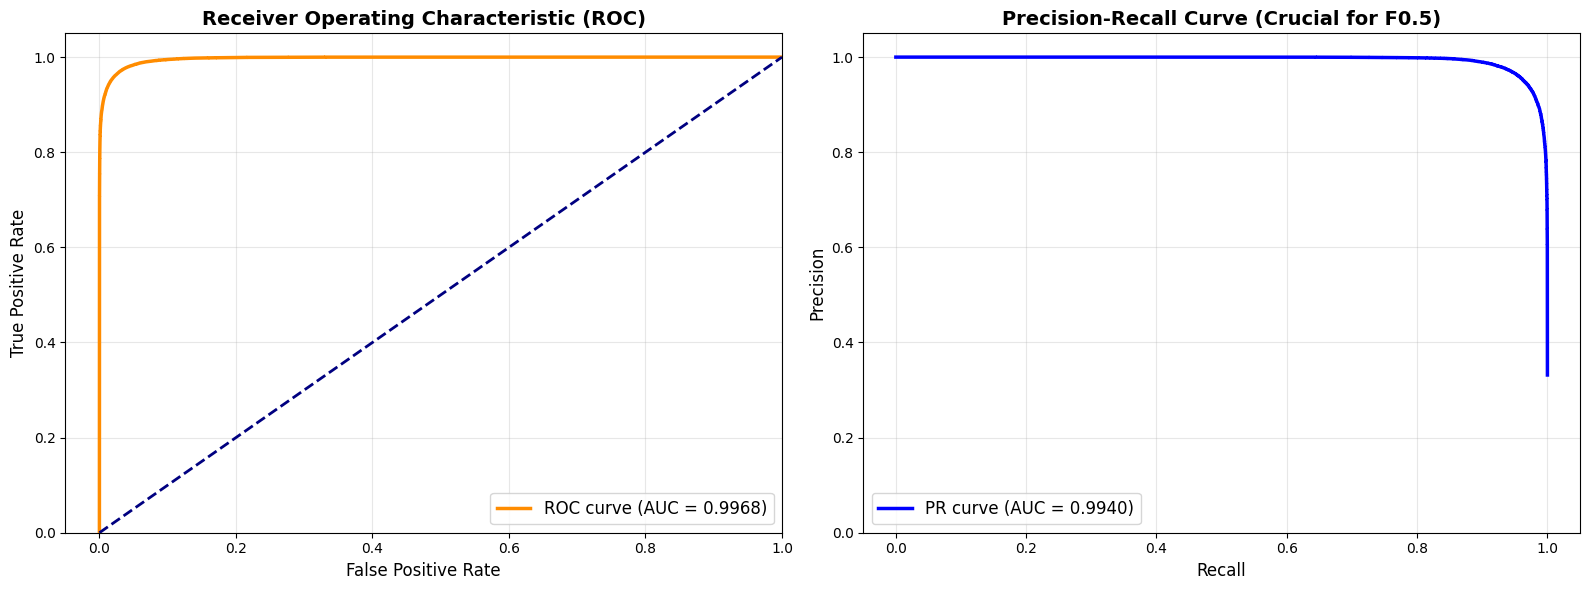


[SUMMARY] Area Under ROC Curve (AUC) : 0.9968
[SUMMARY] Area Under PR Curve (AUC)  : 0.9940


In [7]:
print("[INFO] Generating ROC and Precision-Recall Curves...")
y_true = val_preds['label'].values
y_scores = val_preds['score'].values

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)
pr_auc = auc(recall, precision)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([-0.05, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(recall, precision, color='blue', lw=2.5, label=f'PR curve (AUC = {pr_auc:.4f})')
ax2.set_xlim([-0.05, 1.05])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve (Crucial for F0.5)', fontsize=14, fontweight='bold')
ax2.legend(loc="lower left", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_pr_curves.png")
plt.show()

print(f"\n[SUMMARY] Area Under ROC Curve (AUC) : {roc_auc:.4f}")
print(f"[SUMMARY] Area Under PR Curve (AUC)  : {pr_auc:.4f}")
